## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

print("Churn Modeling Environment Ready ✅")


Churn Modeling Environment Ready ✅


In [2]:
# Load monthly data
customer_month_df = pd.read_csv("../data/raw/customer_month_data.csv")

# Convert month back to datetime
customer_month_df["month"] = pd.to_datetime(customer_month_df["month"])

customer_month_df.head()


,customer_id,month,plan,monthly_price,region,company_size,industry,acquisition_channel,login_count,avg_session_time,feature_usage_score,amount_paid,payment_delay_days,ticket_count,churn
0,CUST_00001,2024-04-01,Basic,999,North India,Small,Healthcare,Organic,3.0,11.29,10.508498,999,0,1,1
1,CUST_00001,2024-05-01,Basic,999,North India,Small,Healthcare,Organic,6.0,19.20,22.112784,999,0,0,1
2,CUST_00001,2024-06-01,Basic,999,North India,Small,Healthcare,Organic,6.0,18.94,19.939134,999,0,1,1
3,CUST_00001,2024-07-01,Basic,999,North India,Small,Healthcare,Organic,9.0,15.43,33.623250,999,0,1,1
4,CUST_00001,2024-08-01,Basic,999,North India,Small,Healthcare,Organic,7.0,11.93,22.317276,999,0,0,1


In [3]:
# --------- Customer-Level Aggregation ---------

customer_features = customer_month_df.groupby("customer_id").agg({
    "login_count": "mean",
    "feature_usage_score": "mean",
    "ticket_count": "mean",
    "payment_delay_days": "mean",
    "amount_paid": "sum",
    "month": "count",
    "plan": "first",
    "region": "first",
    "company_size": "first",
    "industry": "first",
    "acquisition_channel": "first",
    "churn": "first"
}).reset_index()

customer_features.rename(columns={
    "login_count": "avg_login",
    "feature_usage_score": "avg_feature_usage",
    "ticket_count": "avg_ticket_count",
    "payment_delay_days": "avg_payment_delay",
    "amount_paid": "total_revenue",
    "month": "tenure_months"
}, inplace=True)

customer_features.head()


,customer_id,avg_login,avg_feature_usage,avg_ticket_count,avg_payment_delay,total_revenue,tenure_months,plan,region,company_size,industry,acquisition_channel,churn
0,CUST_00001,7.761905,25.666357,1.047619,7.857143,17982,21,Basic,North India,Small,Healthcare,Organic,1
1,CUST_00002,9.500000,29.965724,0.700000,1.400000,9990,10,Basic,North India,Small,Finance,Organic,0
2,CUST_00003,8.187500,27.955596,0.625000,5.750000,14985,16,Basic,South India,Medium,Tech,Referral,1
3,CUST_00004,8.523810,26.557140,0.666667,8.476190,17982,21,Basic,International,Medium,Healthcare,Organic,1
4,CUST_00005,22.727273,70.711091,0.772727,4.318182,49980,22,Pro,South India,Large,Finance,Paid Ads,0


In [4]:
print("Shape:", customer_features.shape)


Shape: (20000, 13)


## Feature Engineering

In [5]:
# --------- Prepare Features for Modeling ---------

# Drop ID
df_model = customer_features.drop(columns=["customer_id"])

# Separate target
X = df_model.drop(columns=["churn"])
y = df_model["churn"]

# Encode categorical variables
categorical_cols = ["plan", "region", "company_size", "industry", "acquisition_channel"]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Feature Matrix Shape:", X.shape)


Feature Matrix Shape: (20000, 18)


In [6]:
# --------- Train/Test Split ---------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)


Train Size: (16000, 18)
Test Size: (4000, 18)


**Logistic Regression**

In [7]:
# --------- Logistic Regression Baseline ---------

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall:", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_log), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_log), 4))


Accuracy: 0.808
Precision: 0.6349
Recall: 0.051
F1 Score: 0.0943
ROC-AUC: 0.7688


C:\Users\gokul\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


“Although logistic regression achieved 80% accuracy, it demonstrated very low recall (5%), indicating poor churn detection due to class imbalance.”

In [8]:
# --------- Logistic Regression (Balanced) ---------

log_model_bal = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model_bal.fit(X_train, y_train)

y_pred_bal = log_model_bal.predict(X_test)
y_prob_bal = log_model_bal.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_bal), 4))
print("Precision:", round(precision_score(y_test, y_pred_bal), 4))
print("Recall:", round(recall_score(y_test, y_pred_bal), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_bal), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_bal), 4))


Accuracy: 0.6375
Precision: 0.3337
Recall: 0.8497
F1 Score: 0.4792
ROC-AUC: 0.7691


C:\Users\gokul\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


“By adjusting class weights, recall improved from 5% to 85%, significantly enhancing churn detection capability despite a drop in raw accuracy.”

**XgBoost**

In [9]:
# --------- XGBoost Model ---------

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))


C:\Users\gokul\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:03:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6565
Precision: 0.3444
Recall: 0.8306
F1 Score: 0.4869
ROC-AUC: 0.7818


“After addressing class imbalance, XGBoost achieved 83% recall and a ROC-AUC of 0.78, significantly outperforming baseline logistic regression for churn detection.”

In [10]:
# --------- Feature Importance ---------

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(10)


,feature,importance
0,avg_login,0.356776
8,region_North India,0.102093
5,tenure_months,0.101621
3,avg_payment_delay,0.077415
4,total_revenue,0.044644
1,avg_feature_usage,0.038686
7,plan_Pro,0.029918
2,avg_ticket_count,0.029410
6,plan_Enterprise,0.027282
14,industry_Retail,0.025307


“Feature importance analysis indicated that engagement level (avg login frequency) was the dominant churn driver, followed by tenure and payment behavior, validating behavioral hypotheses.”

**“In churn prediction, recall is prioritized over precision because failing to detect at-risk customers leads directly to revenue loss, whereas false positives only incur minor retention campaign costs.”**

In [11]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_importance = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)

perm_df.head(10)


,feature,importance
0,avg_login,0.108050
3,avg_payment_delay,0.025658
1,avg_feature_usage,0.024138
4,total_revenue,0.021665
5,tenure_months,0.020309
8,region_North India,0.008342
2,avg_ticket_count,0.005220
17,acquisition_channel_Referral,0.000583
11,company_size_Medium,0.000421
16,acquisition_channel_Paid Ads,0.000239


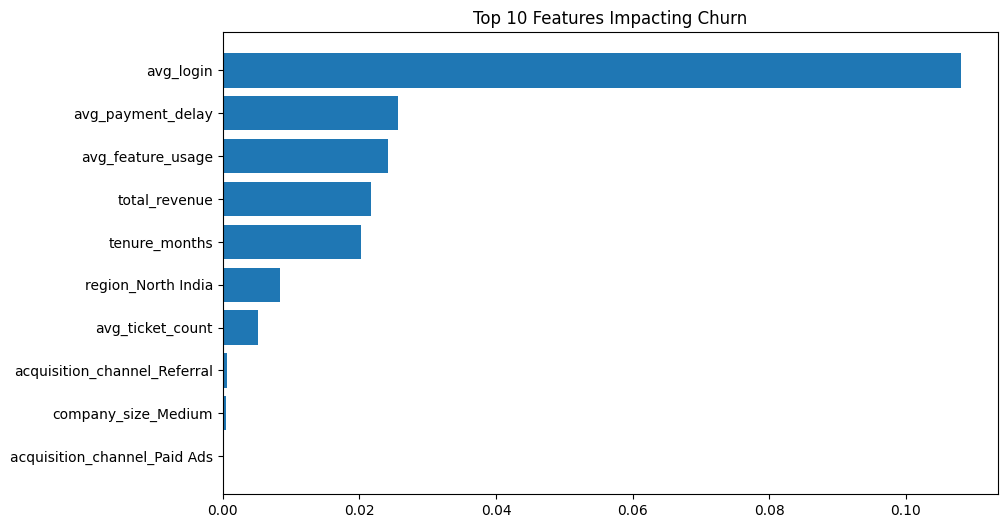

In [12]:
plt.figure(figsize=(10,6))
plt.barh(perm_df.head(10)["feature"], perm_df.head(10)["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Impacting Churn")
plt.show()


**1) avg_login (Strongest Driver)

Massive gap from others.

→ Low engagement = churn
→ Product usage is the key risk signal

2) avg_payment_delay

Customers delaying payments are high churn risk.

Financial behavior = retention signal.

3) avg_feature_usage

Shallow feature adoption → lower product stickiness.

4) total_revenue

Low-value customers churn more.

️5) tenure_months

Early-stage customers are risky.**

In [13]:
import joblib
import os

# Create models folder
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/xgb_churn_model.pkl")

print("Model saved successfully ✅")


Model saved successfully ✅
